In [2]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
import math
from scipy.special import eval_hermite
from scipy.special import hermite
from matplotlib import pyplot as plt
from scipy.integrate import simpson

In [3]:
from functools import lru_cache

@lru_cache(maxsize=None)
def log_normalization_const_squared(nu, n):
    result = np.log(np.sqrt(2 * nu))
    result -= np.log(np.pow(np.pi, 1/2))
    result -= np.log(2) * (2*n)
    result -= math.lgamma(2 * n + 2)
    return result

def HO_energy(n_basis):
    diag = [2*n + 3/2 for n in range(0, n_basis)]
    energy = np.diag(diag)
    return energy


def wavefunction(coefficients, x):
    coefficients = np.asarray(coefficients)
    ks = np.arange(len(coefficients))
    log_norms = np.array([log_normalization_const_squared(0.5, k) for k in ks])
    norm_factors = np.exp(log_norms / 2) / np.sqrt(4 * np.pi)
    
    if x == 0:
        herm_vals = np.array([hermite(2*k+1).deriv()(0) for k in ks])
    else:
        herm_vals = np.array([eval_hermite(2*k+1, x) for k in ks]) / x
    
    return np.sum(norm_factors * coefficients * herm_vals) * np.exp(-x*x / 2)


def precompute_norm_factors(M):
    log_norms = np.array([log_normalization_const_squared(0.5, k) for k in range(M)])
    return np.exp(log_norms / 2) / np.sqrt(4 * np.pi)  # shape: (M,)

def precompute_hermite_matrix(M, x_points):
    return np.array([eval_hermite(2*k+1, x_points) for k in range(M)])

def wavefunction_matrix(coefficients, x_points, hermite_matrix, norm_factors):
    weighted = (norm_factors * coefficients)[:, np.newaxis] * hermite_matrix
    psi_sum = np.sum(weighted, axis=0)

    M = len(coefficients)
    deriv_at_0 = np.array([hermite(2*k+1).deriv()(0) for k in range(M)])
    limit_at_0 = np.sum(norm_factors * coefficients * deriv_at_0) * 1.0  

    with np.errstate(divide='ignore', invalid='ignore'):
        psi = np.where(x_points != 0,
                       psi_sum / x_points * np.exp(-x_points**2 / 2),
                       limit_at_0)
    return psi

def potential_energy(coefficients, nu, N, a):
    M = len(coefficients)
    coefficients = np.asarray(coefficients)
    max_order = 6*M - 2
    points, weights = hermgauss(max_order)

    eta = np.sqrt(0.5)
    x_pts = eta * points

    norm_factors = precompute_norm_factors(M)
    hermite_matrix = precompute_hermite_matrix(M, x_pts)

    psi_vals = wavefunction_matrix(coefficients, x_pts, hermite_matrix, norm_factors)
    psi_no_exp = psi_vals / np.exp(-x_pts**2 / 2) 

    log_norms_nu = np.array([log_normalization_const_squared(nu, k) for k in range(M)])

    result = np.zeros((M, M))
    for n in range(M):
        for m in range(n, M):
            herm_nm = eval_hermite(2*m+1, x_pts) * eval_hermite(2*n+1, x_pts)
            integral = np.sum(weights / 2 * herm_nm * psi_no_exp**2)
            coeff = (N-1)*a * np.sqrt(2)/2 * 4*np.pi * np.exp(
                (log_norms_nu[n] + log_norms_nu[m]) / 2
            )
            result[n, m] = coeff * integral
            result[m, n] = result[n, m]

    return result

def hamiltonian(coefficients, old_coefficients, alpha, nu, N, a):
    M=len(coefficients)
    HO=HO_energy(M)
    potential=(alpha)*potential_energy(coefficients, nu, N, a)+(1-alpha)*potential_energy(old_coefficients, nu, N, a)
    return HO+potential


def true_energy(coefficients, N, a, mu): 
    coefficients = np.asarray(coefficients)
    ho_energy = np.sum(coefficients**2 * (2*np.arange(len(coefficients)) + 1.5))

    x = np.arange(0.001, 10, 0.001)
    M = len(coefficients)
    norm_factors = precompute_norm_factors(M)
    herm_mat = precompute_hermite_matrix(M, x)
    psi = wavefunction_matrix(coefficients, x, herm_mat, norm_factors) 

    wavefunction_integral = (N-1)*a * (4*np.pi)**2 * simpson(psi**4 * x**2, x)
    E = ho_energy + wavefunction_integral / 2
    E_difference = mu - ho_energy - wavefunction_integral
    return E, E_difference


def ground_state(old_coefficients, old_old_coefficients, alpha, nu, N, a):
    energies, vecs = np.linalg.eigh(hamiltonian(old_coefficients, old_old_coefficients, alpha, nu, N, a))
    psi = vecs[:, 0]
    
    if psi[np.argmax(np.abs(psi))] < 0:
        psi = -psi
    
    return energies[0], psi


def plot_state(coefficients, E):
    x = np.arange(0.001, 6, 0.01)
    M = len(coefficients)
    norm_factors = precompute_norm_factors(M)
    herm_mat = precompute_hermite_matrix(M, x)
    y = wavefunction_matrix(np.asarray(coefficients), x, herm_mat, norm_factors)
    plt.plot(x, y*y*x*x*4*np.pi, label=f"E={E:.6f}")
    plt.xlabel("Radial coordinate [h.o. length units]")
    plt.ylabel("Probability density [h.o. length units]$^{-1}$")
    plt.legend(loc='upper right')
    #print("Area=",(simpson(y*y*x*x*4*np.pi,x)))


E at  0  iteration=  1.5398543337273056
Delta_E at  0  iteration=  -0.07970866745461115
E at  1  iteration=  1.5388117507543717
Delta_E at  1  iteration=  -0.037769128822426515
E at  2  iteration=  1.5385272782433548
Delta_E at  2  iteration=  0.0019425524854289333
E at  3  iteration=  1.5385239098055226
Delta_E at  3  iteration=  0.0005514002854308947
E at  4  iteration=  1.538523636645417
Delta_E at  4  iteration=  -8.604955299011674e-05
E at  5  iteration=  1.5385236285768866
Delta_E at  5  iteration=  -1.559043492380119e-05
E at  6  iteration=  1.538523628324152
Delta_E at  6  iteration=  3.73388814492448e-06
E at  7  iteration=  1.5385236283080141
Delta_E at  7  iteration=  4.3041962977108383e-07
Convergence reached with delta_E criterion!
[ 9.99711913e-01  2.31284430e-02 -6.03165328e-03  2.03191248e-03
 -7.48424316e-04  2.85842689e-04 -1.10049655e-04  4.17276418e-05
 -1.51285543e-05  4.96113662e-06 -1.24968370e-06  2.36550283e-08
  2.89162675e-07 -2.97960589e-07  2.27995674e-07 -

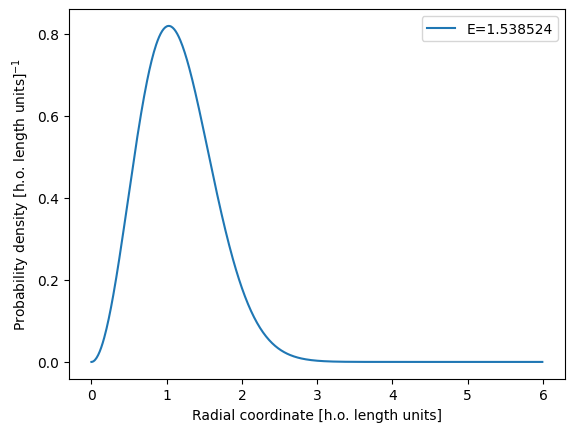

In [17]:
def iterative_GP(first_guess,alpha,nu,N,a,N_iterations,delta_E_stop):
    old_coord=first_guess
    old_old_coord=np.zeros(len(first_guess))
    for i in range(N_iterations):
        new_mu, new_coord=ground_state(old_coord,old_old_coord,alpha,nu,N,a)
        #if i%10==0:
            #plot_state(new_coord,i)
        #print("Mu at ",(i)," iteration= ",(new_mu))
        E, E_difference = true_energy(new_coord, N, a, new_mu)  
        print("E at ",(i)," iteration= ",(E))
        print("Delta_E at ",(i)," iteration= ",(E_difference))
        #print("Normalization=",(np.sum(new_coord**2)))
        if abs(E_difference)<delta_E_stop and i>1:
            print("Convergence reached with delta_E criterion!")
            plot_state(new_coord,E)
            break
        
        old_old_coord=old_coord
        old_coord=new_coord
    return new_mu, E, new_coord

first_guess=np.zeros(40)
#first_guess[0]=1
mixing=0.5
_,_,psi_current=iterative_GP(first_guess,mixing,0.5,1e3,1e-4,201,1e-6)
print(psi_current)



E at 0 iteration= 1.538811709316738
Delta_E at 0 iteration= 0.0010174657738346027
E at 1 iteration= 1.5385861157104588
Delta_E at 1 iteration= 0.0005514267200567996
E at 2 iteration= 1.5385372079369153
Delta_E at 2 iteration= 0.0002736289557130206
E at 3 iteration= 1.5385265850667973
Delta_E at 3 iteration= 0.000131133565221625
E at 4 iteration= 1.5385242734017222
Delta_E at 4 iteration= 6.191376385673852e-05
E at 5 iteration= 1.5385237693578016
Delta_E at 5 iteration= 2.9042591823763564e-05
E at 6 iteration= 1.538523659220707
Delta_E at 6 iteration= 1.358601192431863e-05
E at 7 iteration= 1.5385236350998595
Delta_E at 7 iteration= 6.349067839625522e-06
E at 8 iteration= 1.5385236298041665
Delta_E at 8 iteration= 2.9665065302691973e-06
E at 9 iteration= 1.5385236286384198
Delta_E at 9 iteration= 1.3863545445108594e-06
E at 10 iteration= 1.5385236283810737
Delta_E at 10 iteration= 6.481804643160283e-07
Convergence reached with delta_E criterion!


(np.float64(1.5758028875067445),
 np.float64(1.5385236283810737),
 array([ 9.99712058e-01,  2.31224037e-02, -6.03076720e-03,  2.03189160e-03,
        -7.48539389e-04,  2.85944039e-04, -1.10116589e-04,  4.17670807e-05,
        -1.51502357e-05,  4.97238867e-06, -1.25516648e-06,  2.61003061e-08,
         2.88235639e-07, -2.97742506e-07,  2.28073910e-07, -1.55047656e-07,
         9.86986921e-08, -6.01597307e-08,  3.54755655e-08, -2.03248311e-08,
         1.13155664e-08, -6.09940200e-09,  3.15521482e-09, -1.53820682e-09,
         6.78848931e-10, -2.41907372e-10,  3.41824047e-11,  5.33703929e-11,
        -8.09049609e-11,  8.06993967e-11, -6.94484414e-11,  5.53320678e-11,
        -4.20102782e-11,  3.08376305e-11, -2.20625194e-11,  1.54570179e-11,
        -1.06334445e-11,  7.19272758e-12, -4.78539236e-12,  3.12932125e-12]))

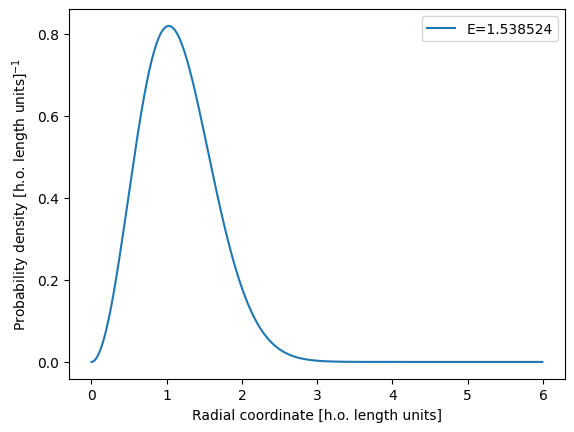

In [ ]:
def iterative_GP_coeff_mixing(first_guess, alpha, nu, N, a, N_iterations, delta_E_stop):
    old_coord = first_guess.copy()
    old_coord /= np.linalg.norm(old_coord)

    for i in range(N_iterations):
        new_mu, new_coord = ground_state(old_coord, old_coord, 1.0, nu, N, a)

        mixed_coord = alpha * new_coord + (1 - alpha) * old_coord
        mixed_coord /= np.linalg.norm(mixed_coord)

        E, E_difference = true_energy(mixed_coord, N, a, new_mu)

        print(f"E at {i} iteration= {E}")
        print(f"Delta_E at {i} iteration= {E_difference}")

        #if i % 10 == 0:
            #plot_state(mixed_coord, E)

        if abs(E_difference) < delta_E_stop and i > 1:
            print("Convergence reached with delta_E criterion!")
            plot_state(mixed_coord, E)
            break

        old_coord = mixed_coord

    return new_mu, E, mixed_coord

first_guess=np.zeros(40)
first_guess[0]=1
mixing=0.5
iterative_GP_coeff_mixing(first_guess,mixing,0.5,1e3,1e-4,401,1e-6)


Iter   0 | E=1.50398475 | ΔE=6.96e-07 | dt=1.00e-02
Iter   1 | E=1.50398407 | ΔE=7.10e-07 | dt=1.05e-02
Iter   2 | E=1.50398340 | ΔE=7.23e-07 | dt=1.10e-02
Convergenza!
Iter   0 | E=1.53978577 | ΔE=6.95e-05 | dt=1.00e-02
Iter   1 | E=1.53971820 | ΔE=7.06e-05 | dt=1.05e-02
Iter   2 | E=1.53965175 | ΔE=7.15e-05 | dt=1.10e-02
Iter   3 | E=1.53958654 | ΔE=7.24e-05 | dt=1.16e-02
Iter   4 | E=1.53952267 | ΔE=7.32e-05 | dt=1.22e-02
Iter   5 | E=1.53946027 | ΔE=7.40e-05 | dt=1.28e-02
Iter   6 | E=1.53939943 | ΔE=7.46e-05 | dt=1.34e-02
Iter   7 | E=1.53934026 | ΔE=7.51e-05 | dt=1.41e-02
Iter   8 | E=1.53928287 | ΔE=7.55e-05 | dt=1.48e-02
Iter   9 | E=1.53922734 | ΔE=7.58e-05 | dt=1.55e-02
Iter  10 | E=1.53917377 | ΔE=7.59e-05 | dt=1.63e-02
Iter  11 | E=1.53912223 | ΔE=7.60e-05 | dt=1.71e-02
Iter  12 | E=1.53907281 | ΔE=7.59e-05 | dt=1.80e-02
Iter  13 | E=1.53902556 | ΔE=7.56e-05 | dt=1.89e-02
Iter  14 | E=1.53898055 | ΔE=7.52e-05 | dt=1.98e-02
Iter  15 | E=1.53893783 | ΔE=7.47e-05 | dt=2.08e-02

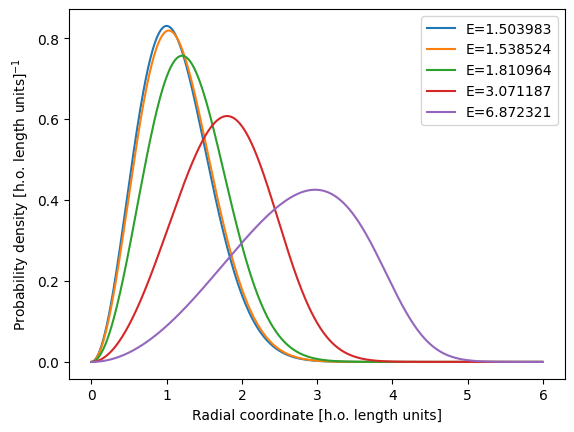

In [9]:
def imaginary_time_GP(first_guess, nu, N, a, N_iterations, delta_E_stop, dt=1e-2):
    psi = first_guess.copy().astype(float)
    psi /= np.linalg.norm(psi)
    E_old = np.inf

    for i in range(N_iterations):
        H = hamiltonian(psi, psi, 1.0, nu, N, a)

        psi_new = psi - dt * (H @ psi)
        psi_new /= np.linalg.norm(psi_new)

        E, E_difference = true_energy(psi_new, N, a, np.dot(psi_new, H @ psi_new))

        print(f"Iter {i:3d} | E={E:.8f} | ΔE={E_difference:.2e} | dt={dt:.2e}")

        if E > E_old + 1e-10:
            dt *= 0.5
            print(f"  → E aumentata, dt ridotto a {dt:.2e}")
            psi_new = psi  
        else:
            dt *= 1.05  
            dt = min(dt, 1e-1)

        #if i % 10 == 0:
        #    plot_state(psi_new, E)

        if abs(E_difference) < delta_E_stop and i>1:
            print("Convergenza!")
            plot_state(psi_new, E)
            break

        psi = psi_new
        E_old = E

    else:
        print("Convergenza non raggiunta.")

    return E, psi

# Chiamata
first_guess = np.zeros(30)
first_guess[0]=1


for a in [1e-5,1e-4,1e-3,1e-2,1e-1]:
    imaginary_time_GP(first_guess,0.5,1e3,a,301,1e-6)